In [1]:
import torch
from torch import autograd
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt
from kan import KAN, LBFGS
import torch.nn as nn # Import nn module
from torchdiffeq import odeint_adjoint as odeint # or odeint for non-adjoint method
import numpy as np

# --- 1. 参数设置 ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.set_default_dtype(torch.float64)
torch.manual_seed(123)
np.random.seed(123)

# --- 2. KAN 模型定义 ---
state_dim = 3
kan_hidden_dims = 4

# --- New: Wrap KAN into an nn.Module for odeint_adjoint ---
class KAN_ODE_Function(nn.Module):
    def __init__(self, kan_model):
        super(KAN_ODE_Function, self).__init__()
        self.kan_model = kan_model

    def forward(self, u):
        # t is provided by odeint, but we only use u
        # KAN expects batch input, so unsqueeze u
        # u will be (batch_size, state_dim) if odeint processes in batches,
        # or (state_dim,) if odeint passes one by one (then unsqueeze needed).
        # To be safe, we'll ensure it's (batch_size, state_dim) for KAN.
        if u.dim() == 1: # If u is (state_dim,), make it (1, state_dim)
            u_input = u.unsqueeze(0)
        else: # If u is already (batch_size, state_dim)
            u_input = u
            
        # Ensure input tensor to KAN model has requires_grad=True
        u_input.requires_grad_(True) 

        # Forward pass through KAN
        output = self.kan_model(u_input)
        
        # Ensure output matches expected shape for odeint (batch_size, state_dim) or (state_dim,)
        if u.dim() == 1:
            return output.squeeze(0) # Remove batch dim if it was added
        else:
            return output


# --- Define the KAN model ---
model_f_raw = KAN(width=[state_dim, kan_hidden_dims, state_dim], grid=10, k=3, 
                  seed=42, device=device)

ModuleNotFoundError: No module named 'kan'

In [1]:
# u_true shape: (2001, d)
u_true = np.load('../dataset/test_trajectories.npy')  # shape: (2001, 2)
u_true = torch.from_numpy(u_true).double().to(device)

# 计算 Δt
num_time_points = u_true.shape[0]
t_start, t_end = 0.0, 200.0
t_span = torch.linspace(t_start, t_end, num_time_points, device=device)
dt = t_span[1] - t_span[0]  # 标量

# 构造所有 input-target 对
u_input_list = []
u_target_list = []

for i in range(u_true.shape[0]):  # 遍历每条轨迹
    u_true_1 = u_true[i]  # shape: (500, d)
    u_input = u_true_1[:-1]   # (499, d)
    u_target = u_true_1[1:]   # (499, d)
    u_input_list.append(u_input)
    u_target_list.append(u_target)

# 拼接成一个大样本集
u_input_all = torch.cat(u_input_list, dim=0)    # shape: (4990, d)
u_target_all = torch.cat(u_target_list, dim=0)  # shape: (4990, d)
u_input_all

NameError: name 'np' is not defined

In [3]:
# --- Instantiate the wrapper ---
model_f = KAN_ODE_Function(model_f_raw) # Pass the KAN model to the wrapper
# --- 4. 损失函数定义 (使用 RK4 单步积分) ---
def loss_fn_rk4(u_input, u_target, dt, model_f):
    # 确保 u_input 具有梯度，以便 KAN 内部计算能够反向传播
    # KAN 通常会处理输入张量的requires_grad，但这里显式声明以确保
    u_input_rk4 = u_input.clone().detach().requires_grad_(True)

    # RK4 步进
    k1 = model_f(u_input_rk4)
    # u + (dt/2) * k1
    u_mid1 = u_input_rk4 + (dt / 2) * k1
    k2 = model_f(u_mid1)
    
    # u + (dt/2) * k2
    u_mid2 = u_input_rk4 + (dt / 2) * k2
    k3 = model_f(u_mid2)
    
    # u + dt * k3
    u_end = u_input_rk4 + dt * k3
    k4 = model_f(u_end)
    
    # RK4 预测的 u(t + dt)
    u_predicted_next = u_input_rk4 + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    
    # 计算均方误差
    loss = torch.mean((u_predicted_next - u_target) ** 2)
    
    return loss


In [4]:
# # --- 5. 训练循环 ---
# from torch.utils.tensorboard import SummaryWriter # 已导入
# writer = SummaryWriter()

# def train_f_model_rk4():
#     optimizer = LBFGS(model_f.parameters(), lr=1,
#                       history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32)
    
#     steps = 101 # 根据需要调整训练步数
#     pbar = tqdm(range(steps), desc='Training Progress')

#     for step in pbar:
#         def closure():
#             optimizer.zero_grad()
#             # 传入 u_input, u_target, dt 和 model_f
#             loss = loss_fn_rk4(u_input, u_target, dt, model_f)
#             loss.backward()
#             return loss

#         optimizer.step(closure)
#         if step % 10 == 0:
#             current_loss = closure().item()
#             pbar.set_description("Step: %d | Loss: %.16f" % (step, current_loss))
#             writer.add_scalar('Loss/train', current_loss, step)
    
#     print(f"Final Loss: {closure().item():.6f}")

# train_f_model_rk4()
# writer.close()

In [5]:
from torch.utils.data import DataLoader, TensorDataset

# 构建 DataLoader
batch_size = 64  # 可根据显存调整
dataset = TensorDataset(u_input_all, u_target_all)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 换用一阶优化器
optimizer = torch.optim.Adam(model_f.parameters(), lr=1e-3)

steps = 100  # 训练轮数（epochs）
writer = SummaryWriter()

def train_f_model_rk4_batch():
    for epoch in range(steps):
        total_loss = 0.0
        for batch_idx, (u_input, u_target) in enumerate(dataloader):
            loss = loss_fn_rk4(u_input, u_target, dt, model_f)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch} | Loss: {avg_loss:.8f}")
        writer.add_scalar('Loss/train', avg_loss, epoch)

    print("Training finished.")

train_f_model_rk4_batch()
writer.close()


Epoch 0 | Loss: 0.13177619
Epoch 1 | Loss: 0.00606104
Epoch 2 | Loss: 0.00202825
Epoch 3 | Loss: 0.00110608
Epoch 4 | Loss: 0.00069362
Epoch 5 | Loss: 0.00047366
Epoch 6 | Loss: 0.00034654
Epoch 7 | Loss: 0.00027044
Epoch 8 | Loss: 0.00021433
Epoch 9 | Loss: 0.00017590
Epoch 10 | Loss: 0.00014579
Epoch 11 | Loss: 0.00012362
Epoch 12 | Loss: 0.00010740
Epoch 13 | Loss: 0.00009356
Epoch 14 | Loss: 0.00008266
Epoch 15 | Loss: 0.00007346
Epoch 16 | Loss: 0.00006515
Epoch 17 | Loss: 0.00005949
Epoch 18 | Loss: 0.00005387
Epoch 19 | Loss: 0.00004903
Epoch 20 | Loss: 0.00004484
Epoch 21 | Loss: 0.00004181
Epoch 22 | Loss: 0.00003773
Epoch 23 | Loss: 0.00003516
Epoch 24 | Loss: 0.00003250
Epoch 25 | Loss: 0.00003072
Epoch 26 | Loss: 0.00002837
Epoch 27 | Loss: 0.00002657
Epoch 28 | Loss: 0.00002505
Epoch 29 | Loss: 0.00002367
Epoch 30 | Loss: 0.00002217
Epoch 31 | Loss: 0.00002129
Epoch 32 | Loss: 0.00001993
Epoch 33 | Loss: 0.00001903
Epoch 34 | Loss: 0.00001837
Epoch 35 | Loss: 0.00001739
Ep

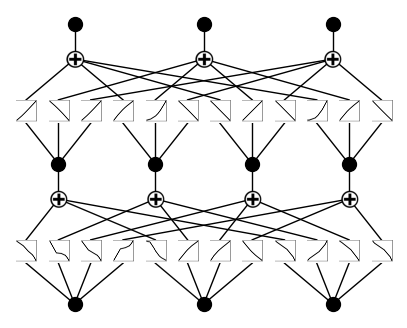

In [6]:
model_f.kan_model.plot()

In [7]:
from kan.utils import ex_round
lib_list = ['x', 'x^2', 'x^3', 'sqrt', 'exp', 'log', 'sin', 'tanh', 'abs'] # Customize library of functions
model_f.kan_model.auto_symbolic(lib=lib_list)
print("Attempted symbolic regression.")
# ex_round(model_f.kan_model.symbolic_formula(), 3)

fixing (0,0,0) with x, r2=0.9842748710459873, c=1
fixing (0,0,1) with x, r2=0.9000242971590995, c=1
fixing (0,0,2) with x, r2=0.9745351157842946, c=1
fixing (0,0,3) with x, r2=0.914704886171465, c=1
fixing (0,1,0) with exp, r2=0.9748918696230277, c=2
fixing (0,1,1) with exp, r2=0.9996340453241517, c=2
fixing (0,1,2) with exp, r2=0.9986515622157095, c=2
fixing (0,1,3) with exp, r2=0.9998463708708321, c=2
fixing (0,2,0) with exp, r2=0.9990114740857953, c=2
fixing (0,2,1) with x, r2=0.9782528904750869, c=1
fixing (0,2,2) with x^2, r2=0.9999125752300999, c=2
fixing (0,2,3) with x, r2=0.9763757802909114, c=1
fixing (1,0,0) with exp, r2=0.9997954534522102, c=2
fixing (1,0,1) with exp, r2=0.9999894742316717, c=2
fixing (1,0,2) with exp, r2=0.9999208233706721, c=2
fixing (1,1,0) with exp, r2=0.9999780434050908, c=2
fixing (1,1,1) with exp, r2=0.9957389133890798, c=2
fixing (1,1,2) with exp, r2=0.9999984993844137, c=2
fixing (1,2,0) with exp, r2=0.9999874752437039, c=2
fixing (1,2,1) with exp, 

In [12]:
ex_round(model_f.kan_model.symbolic_formula()[0][0], 4)

0.1207*exp(-0.1173*x_1 - 0.0619*exp(1.6*x_3) + 0.027*exp(-1.2*x_2)) - 0.2406*exp(-0.0923*x_1 - 0.037*(-x_3 - 0.18)**2 - 0.026*exp(-2.4*x_2)) - 0.0261*exp(0.3951*x_1 - 0.5127*x_3 + 0.2802*exp(-2.2*x_2)) + 0.0006*exp(1.74*x_1 - 1.3884*x_3 + 1.2111*exp(-2.0*x_2)) + 0.1501

In [13]:
ex_round(model_f.kan_model.symbolic_formula()[0][1], 4)

0.0034*exp(-0.8231*x_1 + 1.0681*x_3 - 0.5838*exp(-2.2*x_2)) - 0.0251*exp(-0.5093*x_1 + 0.4064*x_3 - 0.3545*exp(-2.0*x_2)) - 0.0533*exp(-0.128*x_1 - 0.0676*exp(1.6*x_3) + 0.0295*exp(-1.2*x_2)) - 0.2675*exp(0.0461*x_1 + 0.0185*(-x_3 - 0.18)**2 + 0.013*exp(-2.4*x_2)) + 0.3386

In [14]:
ex_round(model_f.kan_model.symbolic_formula()[0][2], 4)

0.0606*exp(-0.096*x_1 - 0.0507*exp(1.6*x_3) + 0.0221*exp(-1.2*x_2)) - 0.1593*exp(-0.0923*x_1 - 0.037*(-x_3 - 0.18)**2 - 0.026*exp(-2.4*x_2)) + 0.2083*exp(-0.0849*x_1 + 0.0677*x_3 - 0.0591*exp(-2.0*x_2)) - 0.1035*exp(-0.0823*x_1 + 0.1068*x_3 - 0.0584*exp(-2.2*x_2)) - 0.0028

In [11]:
# 把 model_f 保存为checkpoint
torch.save(model_f.state_dict(), './model/model_f.pth')